# Regression without `max_gfa` and `accommodation_value`

In [55]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

## Dataset

In [2]:
df = pd.read_csv("../data/transformation2.csv", header = 0)
df.head()

,adj_premium_per_sqm,latitude,longitude,FEDFUNDS,RGDP(Billions),in_als,sale_regime,n_tenderers,award_date
0,674.491364,22.382232,113.972443,4.74,166.73242,0,govt-led,6.0,1999-04-08
1,546.423925,22.265657,114.152386,4.74,166.73242,0,govt-led,6.0,1999-04-08
2,2375.991499,22.286157,114.196417,4.74,166.73242,0,govt-led,6.0,1999-04-20
3,1210.780185,22.341967,114.183563,4.74,166.73242,0,govt-led,6.0,1999-04-20
4,1123.492385,22.266436,114.151844,4.76,166.73242,0,govt-led,6.0,1999-06-29


### Preliminary Transformations

In [12]:
df = df.rename(columns={'RGDP(Billions)': 'RGDP'})
df['log_adj_premium_per_sqm'] = np.log(df['adj_premium_per_sqm'])
df['log_RGDP'] = np.log(df['RGDP'])
df['log_n_tenderers'] = np.log(df['n_tenderers'])

### Add New Dummy Variable

In [29]:
df['during_als'] = np.where(df['award_date'] < "2013-02-01", 1, 0)

In [30]:
df.head()

,adj_premium_per_sqm,latitude,longitude,FEDFUNDS,RGDP,in_als,sale_regime,n_tenderers,award_date,log_adj_premium_per_sqm,log_RGDP,log_n_tenderers,during_als
0,674.491364,22.382232,113.972443,4.74,166.73242,0,govt-led,6.0,1999-04-08,6.513959,5.11639,1.791759,1
1,546.423925,22.265657,114.152386,4.74,166.73242,0,govt-led,6.0,1999-04-08,6.303395,5.11639,1.791759,1
2,2375.991499,22.286157,114.196417,4.74,166.73242,0,govt-led,6.0,1999-04-20,7.773170,5.11639,1.791759,1
3,1210.780185,22.341967,114.183563,4.74,166.73242,0,govt-led,6.0,1999-04-20,7.099020,5.11639,1.791759,1
4,1123.492385,22.266436,114.151844,4.76,166.73242,0,govt-led,6.0,1999-06-29,7.024197,5.11639,1.791759,1


### Preliminary Datachecks

In [ ]:
pd.crosstab(df['in_als'], df['sale_regime'])

sale_regime,ALS,govt-led
in_als,,
0,0,135
1,40,69


In [33]:
pd.crosstab(df['during_als'], df['sale_regime'])

sale_regime,ALS,govt-led
during_als,,
0,0,132
1,40,72


In [31]:
pd.crosstab(df['in_als'], df['during_als'])

during_als,0,1
in_als,,
0,107,28
1,25,84


+ There are `0` land sites that were sold under ALS regime but not listed as ALS. This is to be expected. 
+ There are `40` sites that were listed in ALS and sold under ALS 
+ There are `69` sites that were listed in ALS but ultimately sold under government-led auctions.
+ There are `135` sites that were simply sold under governmen-led auctions and not affected at all by ALS related policies. 

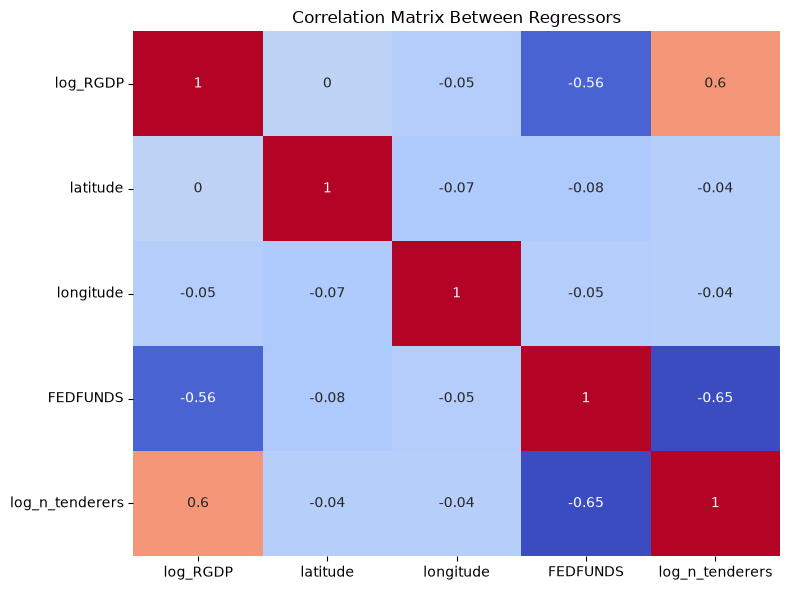

In [14]:
var_corr = ['log_RGDP', 'latitude', 'longitude', 'FEDFUNDS', 'log_n_tenderers']
corr = df[var_corr].corr().round(2)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    cbar=False
)
plt.title("Correlation Matrix Between Regressors")
plt.tight_layout()
plt.show()

## Regressions

In [34]:
model1 = smf.ols(
    """
    log_adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + log_RGDP
    + sale_regime
    + in_als
    + during_als
    + log_n_tenderers
    """,
    data = df
).fit()

print(model1.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.397
Model:                                 OLS   Adj. R-squared:                  0.377
Method:                      Least Squares   F-statistic:                     19.37
Date:                     Tue, 25 Aug 2026   Prob (F-statistic):           2.67e-22
Time:                             10:50:41   Log-Likelihood:                -337.16
No. Observations:                      244   AIC:                             692.3
Df Residuals:                          235   BIC:                             723.8
Df Model:                                8                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [35]:
model2 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + RGDP
    + FEDFUNDS
    + sale_regime
    + in_als
    + during_als
    + n_tenderers
    """, data= df
).fit()

print(model2.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.358
Model:                             OLS   Adj. R-squared:                  0.336
Method:                  Least Squares   F-statistic:                     16.38
Date:                 Tue, 25 Aug 2026   Prob (F-statistic):           3.30e-19
Time:                         10:50:53   Log-Likelihood:                -2201.1
No. Observations:                  244   AIC:                             4420.
Df Residuals:                      235   BIC:                             4452.
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept       

### Interaction Regressions

#### Log Response

In [39]:
model3 = smf.ols(
    """
    log_adj_premium_per_sqm ~
    latitude
    + longitude
    + sale_regime
    + during_als
    + log_RGDP
    + FEDFUNDS
    + log_n_tenderers
    + in_als
    + in_als: during_als
    + in_als: sale_regime
    + in_als: log_RGDP
    + in_als: FEDFUNDS
    + in_als: log_n_tenderers
    """, data=df
).fit()

print(model3.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.422
Model:                                 OLS   Adj. R-squared:                  0.392
Method:                      Least Squares   F-statistic:                     14.07
Date:                     Tue, 25 Aug 2026   Prob (F-statistic):           8.46e-22
Time:                             10:53:59   Log-Likelihood:                -332.02
No. Observations:                      244   AIC:                             690.0
Df Residuals:                          231   BIC:                             735.5
Df Model:                               12                                         
Covariance Type:                 nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

In [40]:
model4 = smf.ols(
    """
    log_adj_premium_per_sqm ~
    latitude
    + longitude
    + sale_regime
    + log_RGDP
    + FEDFUNDS
    + log_n_tenderers
    + in_als: sale_regime
    + in_als: during_als
    + in_als: log_RGDP
    + in_als: FEDFUNDS
    + in_als: log_n_tenderers
    """, data=df
).fit()

print(model4.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.421
Model:                                 OLS   Adj. R-squared:                  0.394
Method:                      Least Squares   F-statistic:                     15.35
Date:                     Tue, 25 Aug 2026   Prob (F-statistic):           2.55e-22
Time:                             10:54:21   Log-Likelihood:                -332.24
No. Observations:                      244   AIC:                             688.5
Df Residuals:                          232   BIC:                             730.5
Df Model:                               11                                         
Covariance Type:                 nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

In [41]:
model5 = smf.ols(
    """
    log_adj_premium_per_sqm ~
    latitude
    + longitude
    + log_RGDP
    + FEDFUNDS
    + log_n_tenderers
    + in_als
    + in_als: sale_regime
    + in_als: during_als
    + in_als: log_RGDP
    + in_als: FEDFUNDS
    + in_als: log_n_tenderers
    """, data=df
).fit()

print(model5.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.421
Model:                                 OLS   Adj. R-squared:                  0.394
Method:                      Least Squares   F-statistic:                     15.35
Date:                     Tue, 25 Aug 2026   Prob (F-statistic):           2.55e-22
Time:                             10:54:54   Log-Likelihood:                -332.24
No. Observations:                      244   AIC:                             688.5
Df Residuals:                          232   BIC:                             730.5
Df Model:                               11                                         
Covariance Type:                 nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

#### Level Response

In [43]:
model6 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + sale_regime
    + during_als
    + RGDP
    + FEDFUNDS
    + log_n_tenderers
    + in_als
    + in_als: sale_regime
    + in_als: during_als
    + in_als: RGDP
    + in_als: FEDFUNDS
    + in_als: n_tenderers
    """, data=df
).fit()

print(model6.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.372
Model:                             OLS   Adj. R-squared:                  0.339
Method:                  Least Squares   F-statistic:                     11.39
Date:                 Tue, 25 Aug 2026   Prob (F-statistic):           7.20e-18
Time:                         10:56:30   Log-Likelihood:                -2198.5
No. Observations:                  244   AIC:                             4423.
Df Residuals:                      231   BIC:                             4468.
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
In

In [45]:
model7 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + sale_regime
    + RGDP
    + during_als
    + FEDFUNDS
    + log_n_tenderers
    + in_als: sale_regime
    + in_als: during_als
    + in_als: RGDP
    + in_als: FEDFUNDS
    + in_als: n_tenderers
    """, data=df
).fit()

print(model7.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.372
Model:                             OLS   Adj. R-squared:                  0.339
Method:                  Least Squares   F-statistic:                     11.39
Date:                 Tue, 25 Aug 2026   Prob (F-statistic):           7.20e-18
Time:                         10:57:01   Log-Likelihood:                -2198.5
No. Observations:                  244   AIC:                             4423.
Df Residuals:                      231   BIC:                             4468.
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Interc

In [46]:
model8 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + RGDP
    + FEDFUNDS
    + during_als
    + n_tenderers
    + in_als
    + in_als: during_als
    + in_als: sale_regime
    + in_als: RGDP
    + in_als: FEDFUNDS
    + in_als: n_tenderers
    """, data=df
).fit()

print(model8.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.378
Model:                             OLS   Adj. R-squared:                  0.346
Method:                  Least Squares   F-statistic:                     11.72
Date:                 Tue, 25 Aug 2026   Prob (F-statistic):           2.27e-18
Time:                         10:57:20   Log-Likelihood:                -2197.2
No. Observations:                  244   AIC:                             4420.
Df Residuals:                      231   BIC:                             4466.
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
In

## Side Interesting Observations

In [51]:
model_n = smf.ols(
    """
    n_tenderers ~
    RGDP 
    + FEDFUNDS
    + in_als
    + sale_regime
    + latitude 
    + longitude
    """, data = df
).fit()

print(model_n.summary())

                            OLS Regression Results                            
Dep. Variable:            n_tenderers   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     74.83
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           6.29e-52
Time:                        11:04:38   Log-Likelihood:                -821.43
No. Observations:                 244   AIC:                             1657.
Df Residuals:                     237   BIC:                             1681.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [48]:
model_n2 = smf.ols(
    """
    n_tenderers ~
    RGDP 
    + FEDFUNDS
    + in_als
    + during_als
    + sale_regime
    + latitude 
    + longitude
    """, data = df
).fit()

print(model_n2.summary())

                            OLS Regression Results                            
Dep. Variable:            n_tenderers   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     73.59
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           8.67e-56
Time:                        11:01:19   Log-Likelihood:                -809.84
No. Observations:                 244   AIC:                             1636.
Df Residuals:                     236   BIC:                             1664.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [52]:
model_n3 = smf.ols(
    """
    n_tenderers ~
    RGDP 
    + FEDFUNDS
    + during_als
    + sale_regime
    + latitude 
    + longitude
    """, data = df
).fit()

print(model_n3.summary())

                            OLS Regression Results                            
Dep. Variable:            n_tenderers   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     49.70
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           2.70e-39
Time:                        11:05:32   Log-Likelihood:                -851.70
No. Observations:                 244   AIC:                             1717.
Df Residuals:                     237   BIC:                             1742.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [54]:
model_n4 = smf.ols(
    """
    n_tenderers ~
    RGDP 
    + FEDFUNDS
    + sale_regime
    + latitude 
    + longitude
    """, data = df
).fit()

print(model_n4.summary())

                            OLS Regression Results                            
Dep. Variable:            n_tenderers   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                     59.81
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           3.63e-40
Time:                        11:08:18   Log-Likelihood:                -851.80
No. Observations:                 244   AIC:                             1716.
Df Residuals:                     238   BIC:                             1737.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [57]:
table = summary_col(
    [model_n4, model_n, model_n3, model_n2],
    stars=True,
    float_format='%0.3f',
    model_names=['Baseline', 'With in_als', 'With during_als', 'With Both'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                         Baseline With in_als With during_als With Both
-----------------------------------------------------------------------
Intercept               306.239   293.653     302.846         327.349  
                        (650.859) (575.900)   (652.024)       (550.399)
sale_regime[T.govt-led] 10.445*** 17.502***   10.731***       16.818***
                        (1.488)   (1.574)     (1.632)         (1.511)  
RGDP                    0.024*    0.049***    0.029           -0.007   
                        (0.013)   (0.012)     (0.019)         (0.016)  
FEDFUNDS                -3.200*** -2.032***   -3.168***       -1.979***
                        (0.314)   (0.312)     (0.323)         (0.299)  
latitude                -10.651   -4.139      -10.111         -7.878   
                        (7.358)   (6.559)     (7.476)         (6.315)  
longitude               -0.532    -1.865      -0.628          -1.266   
                        (5.402)   (4.782)     (5.415)         (

In [ ]:
model_n5 = smf.ols(
    """
    log_n_tenderers ~
    log_RGDP 
    + FEDFUNDS
    + in_als
    + during_als
    + sale_regime
    + latitude 
    + longitude
    """, data = df
).fit()

print(model_n5.summary())

                            OLS Regression Results                            
Dep. Variable:        log_n_tenderers   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     99.57
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           8.33e-67
Time:                        10:51:20   Log-Likelihood:                -193.02
No. Observations:                 244   AIC:                             402.0
Df Residuals:                     236   BIC:                             430.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 